In [62]:

# Functions + imports
#################################################################################################################
# Core libraries for cleaning, grouping, merging, and quick plots.
# (Note: sklearn LinearRegression imported but not used here; ok to keep for later baseline comparisons.)

import pandas as pd
import numpy as np
import src.phasebalance.phase_unbalance_utils as m
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math
try:
    import statsmodels.api as sm
    HAVE_SM = True
except Exception as e:
    HAVE_SM = False
    print("statsmodels not available -> will use ratio-quantile fallback.")
    print("Error:", e)   

FREQ = pd.Timedelta(minutes=15)

def parse_dnr(d): 
    """
    'D0411' -> 411
    'D1354' -> 1354
    """
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")  # remove 'D' and leading zeros
    if digits == "":
        return None
    return int(digits)


def make_expected_grid(df, freq=FREQ):
    """Build full expected 15-min grid per (substation, transformer) over its observed span."""
    out = []
    for (sid, tr), g in df.groupby(["substation_id", "transformer"]):
        t0 = g["ts"].min()
        t1 = g["ts"].max()
        grid = pd.date_range(t0, t1, freq=freq)
        out.append(pd.DataFrame({"substation_id": sid, "transformer": tr, "ts": grid}))
    return pd.concat(out, ignore_index=True)


def compute_ct_diagnostics(
    merged: pd.DataFrame,
    min_points: int = 50,
    min_current: float = 5.0,
) -> pd.DataFrame:
    """
    Per-(substation, transformer) diagnostics to detect CT scaling vs unmetered load.

    Expects columns in merged:
      substation_id, transformer, ts,
      I_total_sm, I_total_jn, n_mps, per_completed

    Assumes:
      - Janitza should be an upper bound for true current
        → in a physically consistent situation, I_total_sm <= I_total_jn
        (ignoring noise / mapping mistakes).
    """
    rows = []

    required = {"substation_id", "transformer", "I_total_sm", "I_total_jn"}
    missing = required - set(merged.columns)
    if missing:
        raise KeyError(f"compute_ct_diagnostics: merged is missing required columns: {sorted(missing)}")

    # Normalize transformer just in case
    m = merged.copy()
    m["transformer"] = m["transformer"].astype(str).str.strip().str.lower()

    for (sid, tr), g in m.groupby(["substation_id", "transformer"], dropna=False):
        g = g.copy()

        # Filter out very low currents (ratios get crazy near zero)
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if len(g) < min_points:
            continue  # not enough data

        x = g["I_total_sm"].to_numpy()
        y = g["I_total_jn"].to_numpy()

        # --- 1) Physical sanity: how often is SMD > Janitza? ---
        sm_gt_jn = (g["I_total_sm"] > g["I_total_jn"])
        frac_sm_gt_jn = float(sm_gt_jn.mean())

        # --- 2) Unconstrained linear fit: y ≈ alpha * x + beta ---
        alpha_ls, beta = np.polyfit(x, y, 1)

        y_pred = alpha_ls * x + beta
        ss_res = float(np.sum((y - y_pred) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # Correlation (shape similarity)
        corr = g["I_total_jn"].corr(g["I_total_sm"])

        # --- 3) Ratio-based view: y/x distribution ---
        ratio = (g["I_total_jn"] / g["I_total_sm"]).replace([np.inf, -np.inf], np.nan).dropna()
        ratio_median = float(ratio.median()) if not ratio.empty else np.nan
        ratio_std = float(ratio.std()) if not ratio.empty else np.nan
        ratio_min = float(ratio.min()) if not ratio.empty else np.nan
        ratio_p05 = float(ratio.quantile(0.05)) if len(ratio) > 0 else np.nan

        # --- 4) "CT scaling" factor under your physical constraint ---
        if float(np.sum(x**2)) > 0:
            alpha0 = float(np.sum(x * y) / np.sum(x**2))
        else:
            alpha0 = np.nan

        alpha_max_phys = ratio_p05  # use ratio_min if you want strict
        if (not np.isnan(alpha0)) and (not np.isnan(alpha_max_phys)):
            alpha_ct = min(alpha0, alpha_max_phys)
        else:
            alpha_ct = np.nan

        # --- 5) Smart-meter completeness & expected alpha from coverage ---
        if "per_completed" in g.columns:
            per_completed = float(pd.to_numeric(g["per_completed"], errors="coerce").max())
            if per_completed > 1.5:  # handle 0–100 scale
                per_completed = per_completed / 100.0
        else:
            per_completed = np.nan

        n_mps = float(pd.to_numeric(g["n_mps"], errors="coerce").max()) if "n_mps" in g.columns else np.nan

        if per_completed and (not np.isnan(per_completed)) and per_completed > 0:
            expected_alpha = 1.0 / per_completed
        else:
            expected_alpha = np.nan

        if (not np.isnan(expected_alpha)) and (not np.isnan(alpha_ct)):
            alpha_over_expected = alpha_ct / expected_alpha
        else:
            alpha_over_expected = np.nan

        rows.append({
            "substation_id": sid,
            "transformer": tr,   # 👈 NEW OUTPUT KEY
            # Unconstrained regression fit (with intercept)
            "alpha_ls": float(alpha_ls),
            "beta": float(beta),
            "r2": float(r2) if not np.isnan(r2) else np.nan,
            "corr": float(corr) if corr is not None else np.nan,
            # Physically constrained CT-like factor
            "alpha_ct": alpha_ct,
            "alpha0_through_origin": alpha0,
            "ratio_min": ratio_min,
            "ratio_p05": ratio_p05,
            "ratio_median": ratio_median,
            "ratio_std": ratio_std,
            # Coverage + expectation
            "per_completed": per_completed,
            "n_mps": n_mps,
            "expected_alpha_from_coverage": expected_alpha,
            "alpha_over_expected": alpha_over_expected,
            # Conservation violation diagnostics
            "frac_sm_gt_jn": frac_sm_gt_jn,
            "n_points": int(len(g)),
        })

    return pd.DataFrame(rows)


def plot_substation_timeseries(merged, sid, alpha=None, max_points=2000):
    g = merged[merged["substation_id"] == sid].sort_values("ts")
    if len(g) > max_points:
        g = g.iloc[:max_points]

    plt.figure(figsize=(12, 4))
    plt.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
    plt.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

    if alpha is not None:
        plt.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD * {alpha:.2f}")

    plt.title(f"Substation {sid} – total current")
    plt.xlabel("Time")
    plt.ylabel("Current [A]")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_substation_scatter(merged, sid, transformer=None, alpha=None):
    g = merged[merged["substation_id"] == sid].copy()
    if transformer is not None:
        g = g[g["transformer"].astype(str).str.strip().str.lower() == str(transformer).strip().lower()]

    if g.empty:
        raise ValueError(f"No rows found for substation_id={sid}, transformer={transformer}")

    plt.figure(figsize=(5, 5))
    plt.scatter(g["I_total_sm"], g["I_total_jn"], s=5, alpha=0.3, label="JD vs SMD")

    max_i = max(g["I_total_sm"].max(), g["I_total_jn"].max())
    plt.plot([0, max_i], [0, max_i], "k--", label="JD = SMD")

    if alpha is not None:
        xs = np.linspace(0, max_i, 100)
        plt.plot(xs, alpha * xs, label=f"JD = {alpha:.2f}·SMD")

    plt.xlabel("SMD I_total [A]")
    plt.ylabel("JD I_total [A]")
    tx = f" | {transformer}" if transformer else ""
    plt.title(f"Substation {sid}{tx} – scatter")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_robust_comparison(stats_df, top_n=300):
    """
    Plots MAE (Amps), RMSE (Amps), and WAPE (%) stacked vertically.
    stats_df is indexed by (substation_id, transformer).
    """
    data = stats_df.head(top_n).copy()

    x = np.arange(len(data))
    width = 0.35
    subs = [f"{sid}_{tr}" for (sid, tr) in data.index]  # 👈 nicer labels

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

    ax1.bar(x - width/2, data["MAE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax1.bar(x + width/2, data["MAE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax1.set_ylabel('MAE [Amps]')
    ax1.set_title(f'Mean Absolute Error (MAE) - Top {top_n} (Substation, Trafo)')
    ax1.legend()
    ax1.grid(True, axis='y', alpha=0.3)

    ax2.bar(x - width/2, data["RMSE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax2.bar(x + width/2, data["RMSE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax2.set_ylabel('RMSE [Amps]')
    ax2.set_title('Root Mean Square Error (RMSE)')
    ax2.grid(True, axis='y', alpha=0.3)

    ax3.bar(x - width/2, data["WAPE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax3.bar(x + width/2, data["WAPE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax3.set_ylabel('WAPE [%]')
    ax3.set_title('Weighted Percentage Error (WAPE)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(subs, rotation=90)
    ax3.grid(True, axis='y', alpha=0.3)

    for i, n in enumerate(data["n_mps"]):
        y_pos = max(data["WAPE_Before"].iloc[i], data["WAPE_After"].iloc[i])
        offset = 0.05 * data["WAPE_Before"].max()
        ax3.text(i, y_pos + offset, f"n={int(n)}", ha='center', fontsize=8, rotation=90)

    plt.tight_layout()
    plt.show()


def plot_substation_timeseries_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    substation_transformers=None,   # NEW: list of (substation_id, transformer) pairs
    min_per_completed: float = 0.7,
    max_plots: int = 12,
    cols: int = 4,
    max_points: int = 2000,
):
    """
    Grid of time series plots per (substation, transformer).

    For each (substation, transformer):
      - plots Janitza I_total_jn
      - plots Smartmeter I_total_sm
      - if alpha_ct is available in `summary`, also plots alpha_ct * I_total_sm
    """

    # Defensive normalize transformer strings
    merged = merged.copy()
    summary = summary.copy()
    if "transformer" not in merged.columns or "transformer" not in summary.columns:
        raise KeyError("Both merged and summary must contain a 'transformer' column.")

    merged["transformer"] = merged["transformer"].astype(str).str.strip().str.lower()
    summary["transformer"] = summary["transformer"].astype(str).str.strip().str.lower()

    # --- choose which (substation, transformer) pairs to plot ---
    if substation_transformers is not None:
        pairs = [(sid, str(tr).strip().lower()) for sid, tr in list(substation_transformers)[:max_plots]]
        cand = summary.merge(
            pd.DataFrame(pairs, columns=["substation_id", "transformer"]),
            on=["substation_id", "transformer"],
            how="inner",
        )
    else:
        cand = summary[summary["per_completed"] >= min_per_completed].copy()

        # Sort by alpha_over_expected if available, else by (substation_id, transformer)
        if "alpha_over_expected" in cand.columns:
            cand = cand.sort_values("alpha_over_expected", ascending=False)
        else:
            cand = cand.sort_values(["substation_id", "transformer"])

        cand = cand.head(max_plots)

        pairs = list(zip(cand["substation_id"], cand["transformer"]))

    if not pairs:
        print("No (substation, transformer) pairs to plot (check filters or substation_transformers).")
        return

    # Lookup diagnostics by (substation_id, transformer)
    summary_idx = summary.set_index(["substation_id", "transformer"])

    # --- create grid of subplots ---
    n_plots = len(pairs)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(6 * cols, 3 * rows),
        sharex=True,
        sharey=False,
    )
    axes = np.array(axes).reshape(-1)

    for ax, (sid, tr) in zip(axes, pairs):
        g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].sort_values("ts")

        if g.empty:
            ax.set_visible(False)
            continue

        if len(g) > max_points:
            g = g.iloc[:max_points]

        # alpha_ct for this (sid, tr)
        alpha = None
        if "alpha_ct" in summary.columns and (sid, tr) in summary_idx.index:
            alpha_val = summary_idx.loc[(sid, tr), "alpha_ct"]
            try:
                alpha = float(alpha_val)
            except Exception:
                alpha = None

        # Plot original currents
        ax.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
        ax.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

        # Optional CT-scaled smartmeter line
        if alpha is not None and np.isfinite(alpha):
            ax.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD × {alpha:.2f}")

        # Title
        title = f"Sub {sid} {tr}"
        if "corr" in summary.columns and (sid, tr) in summary_idx.index:
            try:
                title += f"\nρ={float(summary_idx.loc[(sid, tr), 'corr']):.2f}"
            except Exception:
                pass
        if "per_completed" in summary.columns and (sid, tr) in summary_idx.index:
            try:
                title += f", per={float(summary_idx.loc[(sid, tr), 'per_completed']):.2f}"
            except Exception:
                pass

        ax.set_title(title, fontsize=9)
        ax.set_ylabel("I_total [A]")
        ax.legend(fontsize=8)

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # x-label only on bottom row
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        if row_idx == rows - 1:
            ax.set_xlabel("Time")

    fig.suptitle("Transformer total current – JD vs SM (with CT scaling)", y=0.98)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


def calculate_robust_metrics(df_in, sm_col="I_total_sm", jn_col="I_total_jn", min_current_mape=20.0):
    """
    Calculates row-wise error metrics and aggregates them per (substation_id, transformer).
    Returns a DataFrame indexed by (substation_id, transformer).
    """
    df = df_in.copy()

    # Defensive normalize transformer
    if "transformer" in df.columns:
        df["transformer"] = df["transformer"].astype(str).str.strip().str.lower()
    else:
        raise KeyError("calculate_robust_metrics: df_in must contain a 'transformer' column now.")

    # 1. Basic Difference
    df["diff"] = df[sm_col] - df[jn_col]
    df["abs_diff"] = df["diff"].abs()
    df["sq_diff"] = df["diff"] ** 2

    # 2. Standard MAPE (filtered)
    high_load_mask = df[sm_col] > min_current_mape
    df["mape_filtered"] = np.nan
    df.loc[high_load_mask, "mape_filtered"] = (
        100 * df.loc[high_load_mask, "abs_diff"] / df.loc[high_load_mask, sm_col]
    )

    # 3. SMAPE
    denom = (df[sm_col].abs() + df[jn_col].abs()) / 2
    df["smape"] = 100 * df["abs_diff"] / denom.replace(0, np.nan)

    # --- AGGREGATION (NOW PER substation + transformer) ---
    stats = df.groupby(["substation_id", "transformer"]).agg(
        # Context
        n_points      = (sm_col, "count"),
        n_mps         = ("n_mps", "max"),
        per_completed = ("per_completed", "max"),

        # Absolute Errors (Amps)
        MAE           = ("abs_diff", "mean"),
        RMSE          = ("sq_diff", lambda x: np.sqrt(x.mean())),

        # Percentage Errors
        MAPE_filtered_mean = ("mape_filtered", "mean"),
        SMAPE_mean         = ("smape", "mean"),

        # Sums for WAPE
        sum_abs_diff = ("abs_diff", "sum"),
        sum_sm_total = (sm_col, "sum"),
    )

    stats["WAPE"] = 100 * stats["sum_abs_diff"] / stats["sum_sm_total"].replace(0, np.nan)
    return stats


def plot_scatter_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    min_per_completed: float = 0.9,
    max_plots: int = 12,
    cols: int = 4,
    min_points: int = 50,
    min_current: float = 5.0,
    normalize: bool = True,
):
    """
    Grid of scatter plots for each (substation_id, transformer):
        x = I_total_sm (smartmeters)
        y = I_total_jn (Janitza)

    When normalize=True, both axes in each subplot are scaled so that
    max(I_total_sm, I_total_jn) for that pair becomes 1.0.
    The slope α is preserved.
    """

    # Basic required cols
    for c in ["substation_id", "transformer", "I_total_sm", "I_total_jn"]:
        if c not in merged.columns:
            raise KeyError(f"merged missing column: {c}")
    for c in ["substation_id", "transformer", "per_completed", "n_points", "alpha_ct", "alpha_over_expected", "r2"]:
        if c not in summary.columns:
            raise KeyError(f"summary missing column: {c}")

    # Normalize transformer strings (defensive)
    merged = merged.copy()
    merged["transformer"] = merged["transformer"].astype(str).str.strip().str.lower()
    summary = summary.copy()
    summary["transformer"] = summary["transformer"].astype(str).str.strip().str.lower()

    # Filter to reasonably complete (substation, transformer) groups
    cand = summary[
        (summary["per_completed"] >= min_per_completed) &
        (summary["n_points"] >= min_points)
    ].copy()

    if cand.empty:
        print("No (substation, transformer) groups meet the per_completed and n_points filters.")
        return

    # Sort so the “worst” ones come first
    cand = cand.sort_values("alpha_over_expected", ascending=False).head(max_plots)

    n_plots = len(cand)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(4 * cols, 4 * rows),
        sharex=not normalize,
        sharey=not normalize,
    )
    axes = np.array(axes).reshape(-1)

    # If NOT normalizing, compute global max across selected pairs
    global_max = 0.0
    if not normalize:
        for _, r in cand.iterrows():
            sid = r["substation_id"]
            tr = r["transformer"]
            g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].copy()
            g = g[(g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)]
            if g.empty:
                continue
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            global_max = max(global_max, local_max)

        if global_max == 0:
            print("All filtered groups have zero currents after filtering.")
            return

    # Actual plotting
    for ax, (_, row) in zip(axes, cand.iterrows()):
        sid = row["substation_id"]
        tr = row["transformer"]
        alpha = row["alpha_ct"]
        per_completed = row["per_completed"]
        alpha_over_exp = row["alpha_over_expected"]
        r2 = row["r2"]

        g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].copy()
        g = g[(g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)]
        if g.empty:
            ax.set_visible(False)
            continue

        if normalize:
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            if local_max == 0:
                ax.set_visible(False)
                continue
            x = g["I_total_sm"] / local_max
            y = g["I_total_jn"] / local_max
            xs = np.linspace(0, 1, 100)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            x = g["I_total_sm"]
            y = g["I_total_jn"]
            xs = np.linspace(0, global_max, 100)
            ax.set_xlim(0, global_max)
            ax.set_ylim(0, global_max)

        ax.scatter(x, y, s=5, alpha=0.3)
        ax.plot(xs, xs, "k--", linewidth=1)                 # JD = SMD
        ax.plot(xs, alpha * xs, linewidth=1)                # JD = alpha * SMD

        ax.set_title(
            f"Sub {sid} {tr}\n"
            f"α={alpha:.2f}, r²={r2:.2f}\n"
            f"per={per_completed:.2f}, α/α_exp={alpha_over_exp:.2f}"
        )

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # Axis labels only on outer edges
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        col_idx = i % cols
        if row_idx == rows - 1:
            ax.set_xlabel("I_total_sm (normalized)" if normalize else "I_total_sm [A]")
        if col_idx == 0:
            ax.set_ylabel("I_total_jn (normalized)" if normalize else "I_total_jn [A]")

    plt.suptitle(
        f"JD vs SMD scatter – (substation, trafo) with per_completed ≥ {min_per_completed}",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()


def fit_k_quantile_per_group(df_reg: pd.DataFrame, tau: float = 0.20, min_points: int = 200):
    """
    Fits per-group quantile regression:
      I_total_jn ≈ b + k * I_total_sm_adj
    Returns k_hat and b_hat per (substation_id, transformer) plus QC metrics.

    QC metrics connect to thesis justification:
      - corr_xy, r2_ols: does it look like a strong linear relationship?
      - frac_x_gt_y: how often does SM_adj exceed Janitza? (should be ~0 if mapping/physics OK)
      - frac_neg_resid: how often the fitted model predicts above the data (y < yhat) for a low quantile
    """
    rows = []
    for (sid, tr), g in df_reg.groupby(["substation_id", "transformer"]):
        if len(g) < min_points:
            continue

        x = g["I_total_sm_adj"].to_numpy(dtype=float)
        y = g["I_total_jn"].to_numpy(dtype=float)

        # require positive x for regression stability
        m = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x = x[m]; y = y[m]
        if len(x) < min_points:
            continue

        # --- shape sanity ---
        corr_xy = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan

        # --- physics sanity (raw): how often does SM_adj exceed Janitza? ---
        # This should be near 0 if mapping + scaling are consistent.
        frac_x_gt_y = float(np.mean(x > y))

        per = float(g["per_completed"].iloc[0])

         # Quantile regression with intercept (main diagnostic fit)
        if HAVE_SM:
            X = sm.add_constant(x)  # [1, x]
            try:
                mod = sm.QuantReg(y, X)
                res = mod.fit(q=tau, max_iter=2000)
                b = float(res.params[0])
                k = float(res.params[1])
            except Exception:
                # if solver struggles, fall back to ratio-quantile
                r = y / x
                k = float(np.nanquantile(r, tau))
                b = 0.0
        else:
            # fallback: quantile of ratios (no intercept)
            r = y / x
            k = float(np.nanquantile(r, tau))
            b = 0.0

        # Physics/QC check:
        # For a low quantile fit, residuals should not be massively negative too often.
        yhat = b + k * x
        resid = y - yhat
        frac_neg = float(np.mean(resid < -1e-6))  # tolerance

        # OLS R^2 only for reporting "linearity quality" (NOT used for estimation)
        try:
            k_ols, b_ols = np.polyfit(x, y, 1)
            y_pred = k_ols * x + b_ols
            ss_res = np.sum((y - y_pred)**2)
            ss_tot = np.sum((y - y.mean())**2)
            r2_ols = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        except Exception:
            r2_ols = np.nan

        rows.append({
            "substation_id": sid,
            "transformer": tr,
            "tau": tau,
            "k_hat": k,     # slope estimate (CT scaling candidate)
            "b_hat": b,     # intercept estimate (diagnostic; usually not applied in correction)
            "corr_xy": corr_xy,
            "frac_x_gt_y": frac_x_gt_y,
            "per_completed": per,
            "n_points": int(len(x)),
            "frac_neg_resid": frac_neg,
            "r2_ols": r2_ols,
            "k_hat_log10": np.log10(k) if (k is not None and np.isfinite(k) and k > 0) else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["k_hat"], ascending=False)


def detect_transformer_swaps(df_reg, min_points=2000, corr_gain=0.05):
    """
    Transformer swap detection (thesis: "failure mode / data quality diagnostic")
    --------------------------------------------------------------------------
    If substation has both sp1 and sp2, check whether SM_adj(sp1) correlates more
    with Janitza(sp2) than Janitza(sp1) AND likewise SM_adj(sp2) correlates more
    with Janitza(sp1) than Janitza(sp2).

    If both cross-correlations are better by corr_gain -> flag swap_suspect.
    These groups should be excluded or remapped before interpreting k.
    """
    out = []
    need = ["substation_id", "transformer", "ts", "I_total_sm_adj", "I_total_jn"]
    for c in need:
        if c not in df_reg.columns:
            raise KeyError(f"detect_transformer_swaps: df_reg missing {c}")

    for sid, gs in df_reg.groupby("substation_id"):
        trafos = set(gs["transformer"].astype(str).str.lower().unique())
        if not {"sp1", "sp2"}.issubset(trafos):
            continue

        g1 = gs[gs["transformer"].str.lower() == "sp1"][["ts","I_total_sm_adj","I_total_jn"]].rename(
            columns={"I_total_sm_adj":"x1","I_total_jn":"y1"}
        )
        g2 = gs[gs["transformer"].str.lower() == "sp2"][["ts","I_total_sm_adj","I_total_jn"]].rename(
            columns={"I_total_sm_adj":"x2","I_total_jn":"y2"}
        )

        h = g1.merge(g2, on="ts", how="inner")
        if len(h) < min_points:
            continue

        c11 = h["x1"].corr(h["y1"])  # sp1 with sp1
        c22 = h["x2"].corr(h["y2"])  # sp2 with sp2
        c12 = h["x1"].corr(h["y2"])  # sp1 with sp2 (cross)
        c21 = h["x2"].corr(h["y1"])  # sp2 with sp1 (cross)

        best_same = np.nanmax([c11, c22])
        best_cross = np.nanmax([c12, c21])

        swap = (c12 > c11 + corr_gain) and (c21 > c22 + corr_gain)

        out.append({
            "substation_id": sid,
            "n_points_pair": int(len(h)),
            "corr_sp1": float(c11) if pd.notna(c11) else np.nan,
            "corr_sp2": float(c22) if pd.notna(c22) else np.nan,
            "corr_cross_1to2": float(c12) if pd.notna(c12) else np.nan,
            "corr_cross_2to1": float(c21) if pd.notna(c21) else np.nan,
            "best_same": float(best_same) if pd.notna(best_same) else np.nan,
            "best_cross": float(best_cross) if pd.notna(best_cross) else np.nan,
            "gain_cross_minus_same": float(best_cross - best_same) if pd.notna(best_same) and pd.notna(best_cross) else np.nan,
            "swap_suspect": bool(swap),
        })

    return pd.DataFrame(out).sort_values("gain_cross_minus_same", ascending=False)


def fit_k_no_intercept(df_reg, tau=0.20, min_points=200):
    """
    Fits quantile regression WITHOUT intercept:
      I_total_jn ≈ k0 * I_total_sm_adj
    Often preferred for CT scaling correction because it enforces 0->0 behavior.
    """
    rows = []
    for (sid,tr), g in df_reg.groupby(["substation_id","transformer"]):
        if len(g) < min_points:
            continue
        x = g["I_total_sm_adj"].to_numpy(float)
        y = g["I_total_jn"].to_numpy(float)
        m = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x = x[m]; y = y[m]
        if len(x) < min_points:
            continue

        if HAVE_SM:
            # X is just x, no constant column
            try:
                res = sm.QuantReg(y, x).fit(q=tau, max_iter=2000)
                k0 = float(res.params[0])
            except Exception:
                k0 = float(np.nanquantile(y/x, tau))
        else:
            k0 = float(np.nanquantile(y/x, tau))

        rows.append({"substation_id": sid, "transformer": tr, "tau": tau, "k_hat0": k0, "n_points": len(x)})
    return pd.DataFrame(rows)


def load_and_clean_devices(path):
    """Loads device metadata and ensures unique device_id per row."""
    df = pd.read_csv(path)
    df["device_id"] = pd.to_numeric(df["device_id"], errors="coerce").astype("Int64")
    
    # Keep first occurrence of device_id if duplicates exist
    return (
        df.dropna(subset=["device_id"])
        .drop_duplicates(subset=["device_id"], keep="first")
    )

def prep_janitza_raw(df_jn, df_devices_clean):
    """Merges Janitza timeseries with device metadata and cleans keys."""
    df_jn["device_id"] = pd.to_numeric(df_jn["device_id"], errors="coerce").astype("Int64")
    
    # Enrich with metadata
    df_jn = df_jn.merge(
        df_devices_clean[["device_id", "feeder", "dnr_str"]], 
        on="device_id", 
        how="left"
    )
    
    # Standardization
    df_jn = df_jn.rename(columns={"feeder": "transformer"})
    
    # Parse substation ID (assuming m.parse_dnr exists)
    df_jn["substation_id"] = df_jn["dnr_str"].map(m.parse_dnr)
    
    return df_jn

def normalize_transformer_strings(df):
    """Standardizes transformer names to lowercase/stripped to ensure join safety."""
    if "transformer" in df.columns:
        df["transformer"] = df["transformer"].astype(str).str.strip().str.lower()
    return df

def snap_to_grid(series, freq="15min", tol_seconds=10):
    """
    Snaps timestamps to the nearest 15min bin.
    If closer than `tol` to the floor, snaps to floor. Otherwise snaps to ceil.
    """
    tol = pd.Timedelta(seconds=tol_seconds)
    t_floor = series.dt.floor(freq)
    offset = series - t_floor
    
    # If offset is small, stick to floor; else round up
    return t_floor.where(offset <= tol, series.dt.ceil(freq))

def filter_low_meter_groups(df_sm, df_jn, min_mps=2):
    """Removes groups (substation+transformer) that have too few meters."""
    if "n_mps" not in df_sm.columns:
        print("WARNING: 'n_mps' missing. Skipping filter.")
        return df_sm, df_jn

    # Identify valid groups
    valid_groups = (
        df_sm.groupby(["substation_id", "transformer"])["n_mps"]
        .max()
        .reset_index()
    )
    valid_groups = valid_groups[valid_groups["n_mps"] > min_mps]
    
    print(f"Filtering: Keeping {len(valid_groups)} groups with > {min_mps} meters.")

    # Filter both dataframes
    df_sm_clean = df_sm.merge(valid_groups[["substation_id", "transformer"]], 
                              on=["substation_id", "transformer"], how="inner")
    df_jn_clean = df_jn.merge(valid_groups[["substation_id", "transformer"]], 
                              on=["substation_id", "transformer"], how="inner")
    
    return df_sm_clean, df_jn_clean

#################################################################################################################

In [63]:
# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
CONFIG = {
    "paths": {
        "sm": "../data/smartmeter_15min_all_by_transformer_20250801_20251101_['LPQ_Current_L1_AVG', 'LPQ_Current_L2_AVG', 'LPQ_Current_L3_AVG']_NEWMETH.parquet",
        "jn": "../data/janitza_timeseries_2026-01-23_1936_All_mes.parquet",
        "devices": "../metadata/devices.csv"
    },
    "cols": {
        "join_keys": ["substation_id", "ts", "transformer"],       
    },
    "settings": {
        "min_meters_per_group": 2,
        "time_tolerance_sec": 10
    }
}

# ==============================================================================
# 3. MAIN PIPELINE
# ==============================================================================

# --- A. Load Data ---
print("Loading data...")
df_sm = pd.read_parquet(CONFIG["paths"]["sm"])
df_jn_raw = pd.read_parquet(CONFIG["paths"]["jn"])
df_devices = load_and_clean_devices(CONFIG["paths"]["devices"])

# --- B. Preprocess Janitza (Metadata & Filtering) ---
df_jn_enriched = prep_janitza_raw(df_jn_raw, df_devices)

print(f"Janitza rows before filter: {len(df_jn_enriched)}")
# (Assuming m.filter_devices... handles specific device logic)
df_jn_filtered, _ = m.filter_devices_by_name_pattern(df_jn_enriched, df_devices)
print(f"Janitza rows removed: {len(df_jn_enriched) - len(df_jn_filtered)}")

# --- C. Standardization & Time Alignment ---
# 1. Normalize strings
df_sm = normalize_transformer_strings(df_sm)
df_jn_filtered = normalize_transformer_strings(df_jn_filtered)

# 2. Filter Low-Count Groups
df_sm, df_jn_filtered = filter_low_meter_groups(
    df_sm, df_jn_filtered, min_mps=CONFIG["settings"]["min_meters_per_group"]
)

# 3. Handle Timezones & Types
df_sm["ts"] = pd.to_datetime(df_sm["ts"])
df_jn_filtered["ts"] = pd.to_datetime(df_jn_filtered["ts"], utc=True).dt.tz_localize(None)

# 4. Snap Janitza Times to 15min Grid
df_jn_filtered["ts"] = snap_to_grid(
    df_jn_filtered["ts"], 
    freq="15min", 
    tol_seconds=CONFIG["settings"]["time_tolerance_sec"]
)

# 5. Trim End Dates (ensure SM doesn't run past JN)
max_ts = df_sm["ts"].max()
df_sm = df_sm[df_sm["ts"] < max_ts]
df_jn_filtered = df_jn_filtered[df_jn_filtered["ts"] < max_ts]

# --- D. Aggregation (Handle Janitza Duplicates) ---
# Calculate Total Current
df_jn_filtered["I_total_avg"] = df_jn_filtered[["Ia_avg", "Ib_avg", "Ic_avg"]].sum(axis=1)

# Aggregate to 1 row per bin
df_jn_agg = (
    df_jn_filtered
    .groupby(CONFIG["cols"]["join_keys"], as_index=False)
    .mean(numeric_only=True)
)

# --- E. Create Common Universe (Inner Join) ---
# Instead of building a grid manually, an INNER join naturally finds the intersection
# of bins that exist in BOTH datasets.
print(" aligning datasets to common bins...")

common_bins = df_jn_agg[CONFIG["cols"]["join_keys"]].merge(
    df_sm[CONFIG["cols"]["join_keys"]],
    on=CONFIG["cols"]["join_keys"],
    how="inner"
)

# Filter both main dataframes to this common set this wont be used later on 
df_jn_final = df_jn_agg.merge(common_bins, on=CONFIG["cols"]["join_keys"], how="inner")
df_sm_final = df_sm.merge(common_bins, on=CONFIG["cols"]["join_keys"], how="inner")

# --- F. Sanity Checks ---
print("-" * 40)
print(f"Final Shape JN: {df_jn_final.shape}")
print(f"Final Shape SM: {df_sm_final.shape}")
print(f"Duplicate keys in JN: {df_jn_final.duplicated(CONFIG['cols']['join_keys']).sum()}")
print(f"Duplicate keys in SM: {df_sm_final.duplicated(CONFIG['cols']['join_keys']).sum()}")
print("-" * 40)

Loading data...
Janitza rows before filter: 1024769
Janitza rows removed: 275915
Filtering: Keeping 58 groups with > 2 meters.
 aligning datasets to common bins...
----------------------------------------
Final Shape JN: (501481, 55)
Final Shape SM: (501481, 23)
Duplicate keys in JN: 0
Duplicate keys in SM: 0
----------------------------------------


### Here we compare the Current of the two data sources together and attempt to fix the scaling error
We do a manual CT scale reset, and quantile regression

We are looking at the average values of the current from the janitza the smart meter on the other hand just records one measurement e.g no max/min

Merging Datasets...
Fitting Robust K-Factor for Sub 1399...
--> Fitted K: 1.8947


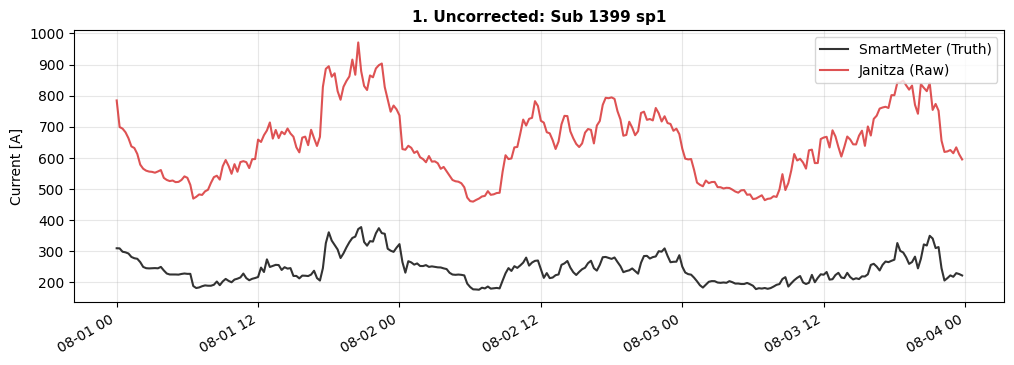

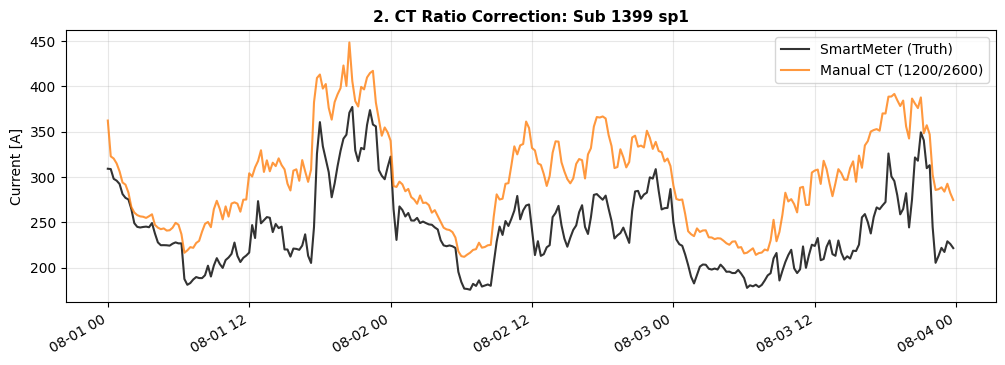

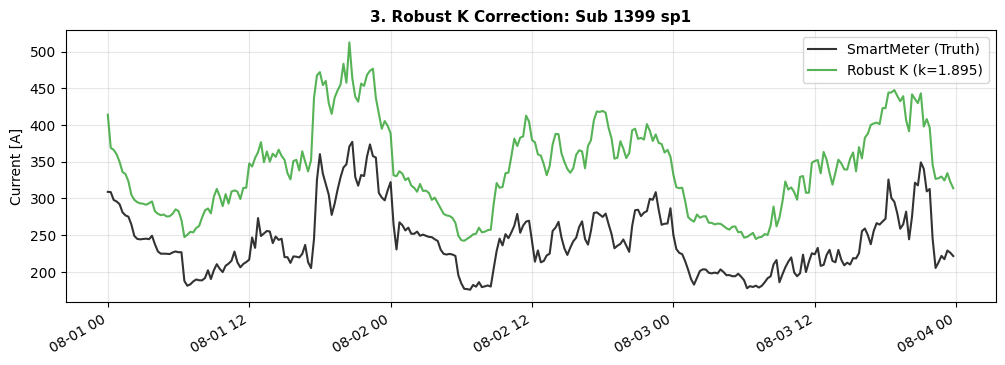

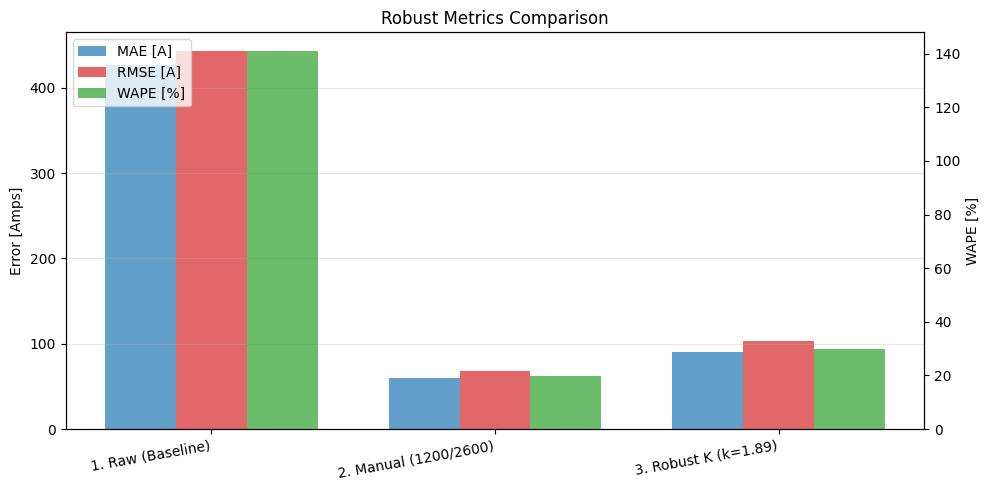

In [64]:
def merge_and_clean(df_sm, df_jn, keep_measurements=None):
    """Merges Smartmeter and Janitza dataframes and calculates differences."""

    # --- NEW: Filter Janitza columns to reduce dataframe size ---
    if keep_measurements:
        # Always keep the join keys + the specific measurements you requested
        keys = ["substation_id", "ts", "transformer"]
        # Validates that columns exist to prevent KeyErrors
        cols_to_keep = keys + [c for c in keep_measurements if c in df_jn.columns and c not in keys]
        df_jn = df_jn[cols_to_keep]
    # ------------------------------------------------------------

    df = df_sm.merge(
        df_jn,
        on=["substation_id", "ts", "transformer"],
        how="inner",
        suffixes=("_sm", "_jn"),
        validate="one_to_one"
    )
    if "Ia_avg" in df.columns:
        # Normalize per_completed to 0.0 - 1.0
        df["per_completed"] = pd.to_numeric(df["per_completed"], errors="coerce")
        mask_pct = df["per_completed"] > 1.5
        df.loc[mask_pct, "per_completed"] = df.loc[mask_pct, "per_completed"] / 100.0
        df.loc[(df["per_completed"] <= 0) | (df["per_completed"] > 1.0), "per_completed"] = np.nan

        # Calculate Adjusted Smartmeter Load (Truth)
        df["I_total_sm_adj"] = df["I_sum_equiv"] / df["per_completed"]  


    return df

def fit_robust_k(df, config):
    """Fits Quantile Regression (y = kx) to find the scaling factor k."""
    # Filter for high quality data points
    mask = (
        (df["I_sum_equiv"].abs() > config["min_current"]) &
        (df["I_total_avg"].abs() > config["min_current"]) &
        (df["per_completed"] >= config["min_coverage"]) &
        np.isfinite(df["I_sum_equiv"]) &
        np.isfinite(df["I_total_avg"])
    )
    df_reg = df[mask]
    
    if len(df_reg) < config["min_points"]:
        print(f"⚠️ Not enough points to fit K ({len(df_reg)} < {config['min_points']}). Defaulting to 1.0")
        return 1.0

    x = df_reg["I_sum_equiv"].values
    y = df_reg["I_total_avg"].values
    tau = config["target_tau"]

    k_val = 1.0
    if HAVE_SM:
        try:
            # QuantReg with no constant forces intercept to 0
            model = sm.QuantReg(y, x)
            res = model.fit(q=tau, max_iter=2000)
            k_val = float(res.params[0])
        except Exception as e:
            print(f"Statsmodels failed: {e}. Using fallback.")
            k_val = float(np.nanquantile(y/x, tau))
    else:
        k_val = float(np.nanquantile(y/x, tau))
        
    return k_val

def plot_analysis_current(df_sub, k_val, config, df_metrics):
    """
    Generates 4 plots for Current with explicit Date Filtering and Time-Series Indexing.
    """
    
    # --- FIX: Ensure Datetime Index and Filter by Config Date Range ---
    df_plot = df_sub.copy()
    
    # 1. Convert 'ts' to datetime and set as index if it isn't already
    if "ts" in df_plot.columns:
        df_plot["ts"] = pd.to_datetime(df_plot["ts"])
        df_plot = df_plot.set_index("ts")
    
    # 2. Sort index (required for slicing)
    df_plot = df_plot.sort_index()
    
    # 3. Apply Date Filtering from Config
    if "start_date" in config and "end_date" in config:
        df_plot = df_plot.loc[config["start_date"]:config["end_date"]]
    # ------------------------------------------------------------------
    
    # Common Plot Settings
    def setup_ax(ax, title, ylabel="Current [A]"):
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)
        # Format x-axis nicely
        fig.autofmt_xdate()

    # --- PLOT 1: Uncorrected (Raw) ---
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(df_plot.index, df_plot["I_sum_equiv"], label="SmartMeter (Truth)", color="black", lw=1.5, alpha=0.8)
    ax1.plot(df_plot.index, df_plot["I_total_avg"], label="Janitza (Raw)", color="tab:red", alpha=0.8)
    setup_ax(ax1, f"1. Uncorrected: Sub {config['sub_id']} {config['trafo_id']}")
    plt.show()

    # --- PLOT 2: CT Ratio Correction ---
    fig, ax2 = plt.subplots(figsize=(12, 4))
    ax2.plot(df_plot.index, df_plot["I_sum_equiv"], label="SmartMeter (Truth)", color="black", lw=1.5, alpha=0.8)
    ax2.plot(df_plot.index, df_plot["I_total_jn_manual"], label=f"Manual CT ({config['ct_real']}/{config['ct_wrong']})", color="tab:orange", alpha=0.8)
    setup_ax(ax2, f"2. CT Ratio Correction: Sub {config['sub_id']} {config['trafo_id']}")
    plt.show()

    # --- PLOT 3: Robust K Correction ---
    fig, ax3 = plt.subplots(figsize=(12, 4))
    ax3.plot(df_plot.index, df_plot["I_sum_equiv"], label="SmartMeter (Truth)", color="black", lw=1.5, alpha=0.8)
    ax3.plot(df_plot.index, df_plot["I_total_jn_corr"], label=f"Robust K (k={k_val:.3f})", color="tab:green", alpha=0.8)
    setup_ax(ax3, f"3. Robust K Correction: Sub {config['sub_id']} {config['trafo_id']}")
    plt.show()

    # --- PLOT 4: Robust Metrics Comparison ---
    fig, ax4 = plt.subplots(figsize=(10, 5))
    
    # Prepare data for bar chart
    labels = df_metrics["Method"]
    x = np.arange(len(labels))
    width = 0.25

    # Bars
    rects1 = ax4.bar(x - width, df_metrics["MAE"], width, label='MAE [A]', color='tab:blue', alpha=0.7)
    rects2 = ax4.bar(x, df_metrics["RMSE"], width, label='RMSE [A]', color='tab:red', alpha=0.7)
    
    # Twin axis for WAPE (%)
    ax4b = ax4.twinx()
    rects3 = ax4b.bar(x + width, df_metrics["WAPE"], width, label='WAPE [%]', color='tab:green', alpha=0.7)

    # Labels & Ticks
    ax4.set_ylabel('Error [Amps]')
    ax4b.set_ylabel('WAPE [%]')
    ax4.set_title('Robust Metrics Comparison')
    ax4.set_xticks(x)
    ax4.set_xticklabels(labels, rotation=10, ha="right")
    
    # Legends
    lines, labs = ax4.get_legend_handles_labels()
    lines2, labs2 = ax4b.get_legend_handles_labels()
    ax4.legend(lines + lines2, labs + labs2, loc='upper left')
    
    ax4.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

CONFIG = {
    "sub_id": 1399,
    "trafo_id": "sp1",
    "start_date": "2025-08-01",
    "end_date": "2025-08-03",
    
    "min_current": 5.0,
    "min_coverage": 0.88,
    "min_points": 200,
    "target_tau": 0.20,
    
    "ct_real": 1200,
    "ct_wrong": 2600,
    "jn_measurements": ["Ia_avg", "Ib_avg", "Ic_avg", "I_total_avg"],
}

# A. Merge Data
print("Merging Datasets...")
df_merged = merge_and_clean(df_sm_final, df_jn_final,keep_measurements=CONFIG["jn_measurements"])

# B. Isolate specific Substation/Transformer for analysis
mask_sub = (df_merged["substation_id"] == CONFIG["sub_id"]) & (df_merged["transformer"] == CONFIG["trafo_id"])
df_sub = df_merged[mask_sub].copy()

if df_sub.empty:
    raise ValueError(f"No data found for Substation {CONFIG['sub_id']} {CONFIG['trafo_id']}")

# C. Fit Robust K-Factor
print(f"Fitting Robust K-Factor for Sub {CONFIG['sub_id']}...")
k_fitted = fit_robust_k(df_sub, CONFIG)
print(f"--> Fitted K: {k_fitted:.4f}")

# D. Apply Corrections
# 1. Robust K Correction: Janitza / k
df_sub["I_total_jn_corr"] = df_sub["I_total_avg"] / k_fitted

# 2. Manual CT Correction: Janitza * (Real/Wrong)
manual_ratio = CONFIG["ct_real"] / CONFIG["ct_wrong"]
df_sub["I_total_jn_manual"] = df_sub["I_total_avg"] * manual_ratio

# E. Calculate Metrics (Using Custom Robust Metrics Function)
metrics_list = []
scenarios = [
    ("I_total_avg", "1. Raw (Baseline)"),
    ("I_total_jn_manual", f"2. Manual ({CONFIG['ct_real']}/{CONFIG['ct_wrong']})"),
    ("I_total_jn_corr", f"3. Robust K (k={k_fitted:.2f})")
]

for col, label in scenarios:
    # Pass df with reset index to access columns cleanly
    stats = calculate_robust_metrics(df_sub.reset_index(), sm_col="I_sum_equiv", jn_col=col)
    stats["Method"] = label
    metrics_list.append(stats)

df_metrics = pd.concat(metrics_list).reset_index(drop=True)

# F. Plot Analysis
plot_analysis_current(df_sub, k_fitted, CONFIG, df_metrics)


### Now we look at the power differnce between meters

Using similar methods as in the current


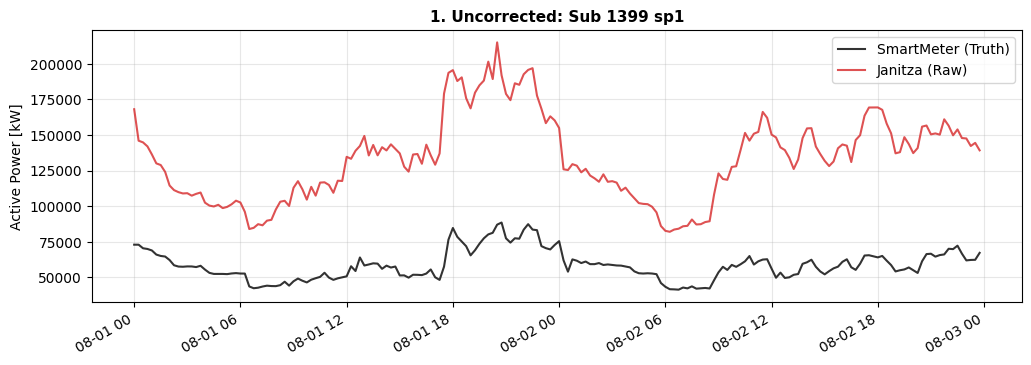

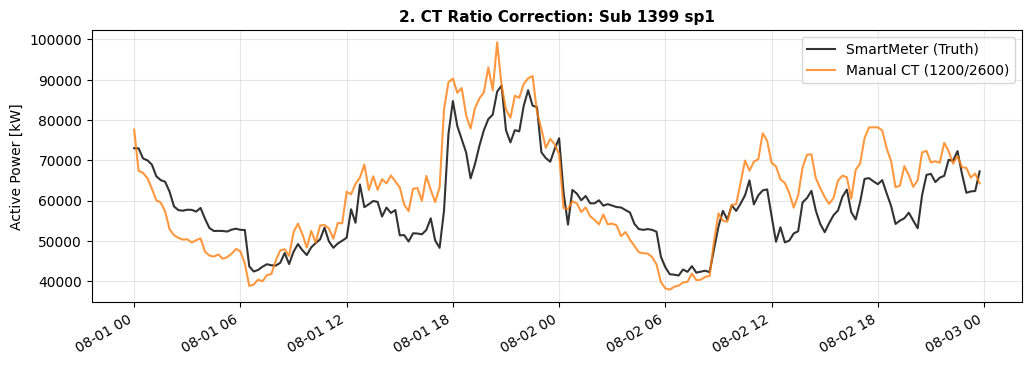

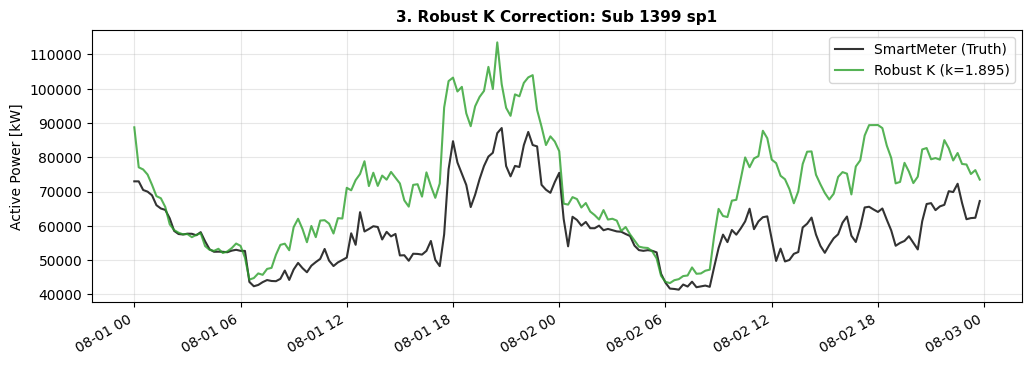

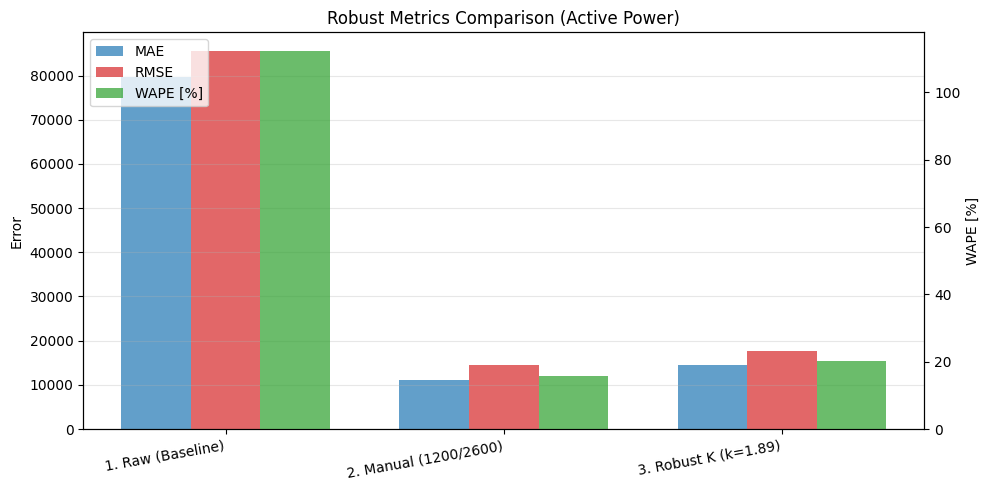

In [ ]:
CONFIG = {
    "sub_id": 1399,
    "trafo_id": "sp1",
    "start_date": "2025-08-01",
    "end_date": "2025-08-02",
    
    "min_current": 5.0,
    "min_coverage": 0.88,
    "min_points": 200,
    "target_tau": 0.20,
    
    "ct_real": 1200,
    "ct_wrong": 2600,
    "jn_measurements": ["Pa_avg", "Pb_avg", "Pc_avg"],
}

def plot_analysis_active_power(df_sub, k_val, config, df_metrics):
    """
    Generates 4 plots for Active Power with explicit Date Filtering and Time-Series Indexing.
    """
    
    # --- FIX: Ensure Datetime Index and Filter by Config Date Range ---
    df_plot = df_sub.copy()
    
    # 1. Convert 'ts' to datetime and set as index if it isn't already
    if "ts" in df_plot.columns:
        df_plot["ts"] = pd.to_datetime(df_plot["ts"])
        df_plot = df_plot.set_index("ts")
    
    # 2. Sort index (required for slicing)
    df_plot = df_plot.sort_index()
    
    # 3. Apply Date Filtering from Config
    if "start_date" in config and "end_date" in config:
        df_plot = df_plot.loc[config["start_date"]:config["end_date"]]
    # ------------------------------------------------------------------

    # Common Plot Settings
    def setup_ax(ax, title, ylabel="Active Power [kW]"):
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)
        # Format x-axis nicely
        fig.autofmt_xdate() 

    # --- PLOT 1: Uncorrected (Raw) ---
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(df_plot.index, df_plot["P_total"], label="SmartMeter (Truth)", color="black", lw=1.5, alpha=0.8)
    ax1.plot(df_plot.index, df_plot["P_total_avg"], label="Janitza (Raw)", color="tab:red", alpha=0.8)
    setup_ax(ax1, f"1. Uncorrected: Sub {config['sub_id']} {config['trafo_id']}")
    plt.show()

    # --- PLOT 2: CT Ratio Correction ---
    fig, ax2 = plt.subplots(figsize=(12, 4))
    ax2.plot(df_plot.index, df_plot["P_total"], label="SmartMeter (Truth)", color="black", lw=1.5, alpha=0.8)
    ax2.plot(df_plot.index, df_plot["P_total_jn_manual"], label=f"Manual CT ({config['ct_real']}/{config['ct_wrong']})", color="tab:orange", alpha=0.8)
    setup_ax(ax2, f"2. CT Ratio Correction: Sub {config['sub_id']} {config['trafo_id']}")
    plt.show()

    # --- PLOT 3: Robust K Correction ---
    fig, ax3 = plt.subplots(figsize=(12, 4))
    ax3.plot(df_plot.index, df_plot["P_total"], label="SmartMeter (Truth)", color="black", lw=1.5, alpha=0.8)
    ax3.plot(df_plot.index, df_plot["P_total_jn_corr"], label=f"Robust K (k={k_val:.3f})", color="tab:green", alpha=0.8)
    setup_ax(ax3, f"3. Robust K Correction: Sub {config['sub_id']} {config['trafo_id']}")
    plt.show()

    # --- PLOT 4: Robust Metrics Comparison ---
    fig, ax4 = plt.subplots(figsize=(10, 5))
    
    # Prepare data for bar chart
    labels = df_metrics["Method"]
    x = np.arange(len(labels))
    width = 0.25

    # Bars
    rects1 = ax4.bar(x - width, df_metrics["MAE"], width, label='MAE', color='tab:blue', alpha=0.7)
    rects2 = ax4.bar(x, df_metrics["RMSE"], width, label='RMSE', color='tab:red', alpha=0.7)
    
    # Twin axis for WAPE (%)
    ax4b = ax4.twinx()
    rects3 = ax4b.bar(x + width, df_metrics["WAPE"], width, label='WAPE [%]', color='tab:green', alpha=0.7)

    # Labels & Ticks
    ax4.set_ylabel('Error')
    ax4b.set_ylabel('WAPE [%]')
    ax4.set_title('Robust Metrics Comparison (Active Power)')
    ax4.set_xticks(x)
    ax4.set_xticklabels(labels, rotation=10, ha="right")
    
    # Legends
    lines, labs = ax4.get_legend_handles_labels()
    lines2, labs2 = ax4b.get_legend_handles_labels()
    ax4.legend(lines + lines2, labs + labs2, loc='upper left')
    
    ax4.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

df_merged = merge_and_clean(df_sm_final, df_jn_final,keep_measurements=CONFIG["jn_measurements"])
df_merged["P_total_avg"] = df_merged[["Pa_avg", "Pb_avg", "Pc_avg"]].sum(axis=1)


# B. Isolate specific Substation/Transformer for analysis
mask_sub = (df_merged["substation_id"] == CONFIG["sub_id"]) & (df_merged["transformer"] == CONFIG["trafo_id"])
df_sub = df_merged[mask_sub].copy()

if df_sub.empty:
    raise ValueError(f"No data found for Substation {CONFIG['sub_id']} {CONFIG['trafo_id']}")

# K_fitted is from the previous fitting step
# D. Apply Corrections
df_sub["P_total_jn_corr"] = df_sub["P_total_avg"] / k_fitted

# 2. Manual CT Correction: Janitza * (Real/Wrong)
manual_ratio = CONFIG["ct_real"] / CONFIG["ct_wrong"]
df_sub["P_total_jn_manual"] = df_sub["P_total_avg"] * manual_ratio


# E. Calculate Metrics (Using Custom Robust Metrics Function)
metrics_list = []
scenarios = [
    ("P_total_avg", "1. Raw (Baseline)"),
    ("P_total_jn_manual", f"2. Manual ({CONFIG['ct_real']}/{CONFIG['ct_wrong']})"),
    ("P_total_jn_corr", f"3. Robust K (k={k_fitted:.2f})")
]

for col, label in scenarios:
    # Pass df with reset index to access columns cleanly
    stats = calculate_robust_metrics(df_sub.reset_index(), sm_col="P_total", jn_col=col)
    stats["Method"] = label
    metrics_list.append(stats)

df_metrics = pd.concat(metrics_list).reset_index(drop=True)

# F. Plot Analysis
plot_analysis_active_power(df_sub, k_fitted, CONFIG, df_metrics)


### Here we can look at the voltage
